# How to set up and test methods: QM9

This file shows how the system works and allows you to check that the datasets are being loaded correctly and are in the correct formats. 

Run this with a subset of the data you plan to test (say the test set) only to see if it works. If it does, then run the python script to set up and save all the topological data as a .hdf5 file, then you only have to create the dataset once.

## Method Followed:

1. Use dummy featurizer or my dummy featurizer to load the molecule information from the `.sdf` file into RDKit objects
2. Create topological feature dataset from dataset
3. Check that things are in the correct format for ML to work (we got random forest and a keras FFNN model). 

Extra stuff:
4. code to look at the data and interrogate the database
5. comparisons to deepchems model on this dataset. 


In [1]:
import sys
sys.path.append(r"C:\Users\ella_\Documents\GitHub\graphs_and_topology_for_chemistry")
sys.path.append(r"C:\Users\ella_\Documents\GitHub\icosahedron_projection")

import deepchem as dc

import tensorflow as tf
import os
import sys
import rdkit
import h5py
import helper_functions as h

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.tri
import rdkit.Chem
import rdkit.Chem.AllChem as Chem
import rdkit.Chem.AllChem as AllChem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors
import mpl_toolkits.mplot3d
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from collections import Counter

print("TensorFlow version: " + tf.__version__)

# topology stuff
from gtda.plotting import plot_point_cloud
from gtda.homology import VietorisRipsPersistence
from gtda.plotting import plot_diagram
from gtda.diagrams import PersistenceEntropy
from gtda.diagrams import NumberOfPoints
from gtda.diagrams import Amplitude
from sklearn.pipeline import make_union, Pipeline

# fixc this at some point
sys.path.append(r"C:\Users\ella_\Documents\GitHub\graphs_and_topology_for_chemistry")
sys.path.append(r"C:\Users\ella_\Documents\GitHub\icosahedron_projection")

import projection
from projection.molecule import Molecule
from projection.pdbmolecule import PDBMolecule
from projection.mol2molecule import Mol2Molecule

import helper_functions as h
#from projection.face import Face

# $UN THIS
save_dir=r'F:\Nextcloud\science\Datasets\converted_pdbbind\v2015'
data_dir=r'F:\Nextcloud\science\Datasets'
results_dir=r"F:\Nextcloud\science\results\topology_and_graphs\QM9"
test_file='qm9.csv'
out_file_name='qm9_topological_features.hdf5'
make_dataset=False # whether to recalc the dataset

name_file_name="INDEX_core_name.2013",
data_file_name="INDEX_core_data.2013",
cluster_file_name = "INDEX_core_cluster.2013"
print(f"DeepChem version: {dc.__version__}")

TensorFlow version: 2.3.0
DeepChem version: 2.5.0


# 1. Load data with no featurization

In [2]:
# This loads the data without doing any featurization
tasks, datasets, transformers = dc.molnet.load_qm9(
    shard_size=2000, featurizer=h.My_Dummy_Featurizer(None), splitter="random")

In [3]:
train_dataset, valid_dataset, test_dataset = datasets

In [4]:
# we're only going to use a small dataset for testing the code here!
my_dataset=test_dataset
num_of_molecules = len(test_dataset)

# 2. Create topological features dataset

This makes the topological features.

In [5]:
topol_feat_list, topol_feat_mat = h.make_topological_features_from_deepchem(my_dataset,
                                          file_type='dc',
                                          verbose=False,
                                          num_of_molecules = num_of_molecules,
                                          num_of_features = 18,
                                          data_dir='',
                                          do_specified_range=False,
                                          selected_range=[])

Doing 18 (3 x 6) topology features:
Persistence entropy
number of points
{'metric': 'bottleneck'}
{'metric': 'wasserstein'}
{'metric': 'landscape'}
{'metric': 'persistence_image'}
Got to Molecule no.  0
Got to Molecule no.  1
Got to Molecule no.  2
Got to Molecule no.  3
Got to Molecule no.  4
Got to Molecule no.  5
Got to Molecule no.  6
Got to Molecule no.  7
Got to Molecule no.  8
Got to Molecule no.  9
Got to Molecule no.  10
Got to Molecule no.  11
Got to Molecule no.  12
Got to Molecule no.  13
Got to Molecule no.  14
Got to Molecule no.  15
Got to Molecule no.  16
Got to Molecule no.  17
Got to Molecule no.  18
Got to Molecule no.  19
Got to Molecule no.  20
Got to Molecule no.  21
Got to Molecule no.  22
Got to Molecule no.  23
Got to Molecule no.  24
Got to Molecule no.  25
Got to Molecule no.  26
Got to Molecule no.  27
Got to Molecule no.  28
Got to Molecule no.  29
Got to Molecule no.  30
Got to Molecule no.  31
Got to Molecule no.  32
Got to Molecule no.  33
Got to Molecul

Got to Molecule no.  325
Got to Molecule no.  326
Got to Molecule no.  327
Got to Molecule no.  328
Got to Molecule no.  329
Got to Molecule no.  330
Got to Molecule no.  331
Got to Molecule no.  332
Got to Molecule no.  333
Got to Molecule no.  334
Got to Molecule no.  335
Got to Molecule no.  336
Got to Molecule no.  337
Got to Molecule no.  338
Got to Molecule no.  339
Got to Molecule no.  340
Got to Molecule no.  341
Got to Molecule no.  342
Got to Molecule no.  343
Got to Molecule no.  344
Got to Molecule no.  345
Got to Molecule no.  346
Got to Molecule no.  347
Got to Molecule no.  348
Got to Molecule no.  349
Got to Molecule no.  350
Got to Molecule no.  351
Got to Molecule no.  352
Got to Molecule no.  353
Got to Molecule no.  354
Got to Molecule no.  355
Got to Molecule no.  356
Got to Molecule no.  357
Got to Molecule no.  358
Got to Molecule no.  359
Got to Molecule no.  360
Got to Molecule no.  361
Got to Molecule no.  362
Got to Molecule no.  363
Got to Molecule no.  364


Got to Molecule no.  653
Got to Molecule no.  654
Got to Molecule no.  655
Got to Molecule no.  656
Got to Molecule no.  657
Got to Molecule no.  658
Got to Molecule no.  659
Got to Molecule no.  660
Got to Molecule no.  661
Got to Molecule no.  662
Got to Molecule no.  663
Got to Molecule no.  664
Got to Molecule no.  665
Got to Molecule no.  666
Got to Molecule no.  667
Got to Molecule no.  668
Got to Molecule no.  669
Got to Molecule no.  670
Got to Molecule no.  671
Got to Molecule no.  672
Got to Molecule no.  673
Got to Molecule no.  674
Got to Molecule no.  675
Got to Molecule no.  676
Got to Molecule no.  677
Got to Molecule no.  678
Got to Molecule no.  679
Got to Molecule no.  680
Got to Molecule no.  681
Got to Molecule no.  682
Got to Molecule no.  683
Got to Molecule no.  684
Got to Molecule no.  685
Got to Molecule no.  686
Got to Molecule no.  687
Got to Molecule no.  688
Got to Molecule no.  689
Got to Molecule no.  690
Got to Molecule no.  691
Got to Molecule no.  692


Got to Molecule no.  981
Got to Molecule no.  982
Got to Molecule no.  983
Got to Molecule no.  984
Got to Molecule no.  985
Got to Molecule no.  986
Got to Molecule no.  987
Got to Molecule no.  988
Got to Molecule no.  989
Got to Molecule no.  990
Got to Molecule no.  991
Got to Molecule no.  992
Got to Molecule no.  993
Got to Molecule no.  994
Got to Molecule no.  995
Got to Molecule no.  996
Got to Molecule no.  997
Got to Molecule no.  998
Got to Molecule no.  999
Got to Molecule no.  1000
Got to Molecule no.  1001
Got to Molecule no.  1002
Got to Molecule no.  1003
Got to Molecule no.  1004
Got to Molecule no.  1005
Got to Molecule no.  1006
Got to Molecule no.  1007
Got to Molecule no.  1008
Got to Molecule no.  1009
Got to Molecule no.  1010
Got to Molecule no.  1011
Got to Molecule no.  1012
Got to Molecule no.  1013
Got to Molecule no.  1014
Got to Molecule no.  1015
Got to Molecule no.  1016
Got to Molecule no.  1017
Got to Molecule no.  1018
Got to Molecule no.  1019
Got t

Got to Molecule no.  1297
Got to Molecule no.  1298
Got to Molecule no.  1299
Got to Molecule no.  1300
Got to Molecule no.  1301
Got to Molecule no.  1302
Got to Molecule no.  1303
Got to Molecule no.  1304
Got to Molecule no.  1305
Got to Molecule no.  1306
Got to Molecule no.  1307
Got to Molecule no.  1308
Got to Molecule no.  1309
Got to Molecule no.  1310
Got to Molecule no.  1311
Got to Molecule no.  1312
Got to Molecule no.  1313
Got to Molecule no.  1314
Got to Molecule no.  1315
Got to Molecule no.  1316
Got to Molecule no.  1317
Got to Molecule no.  1318
Got to Molecule no.  1319
Got to Molecule no.  1320
Got to Molecule no.  1321
Got to Molecule no.  1322
Got to Molecule no.  1323
Got to Molecule no.  1324
Got to Molecule no.  1325
Got to Molecule no.  1326
Got to Molecule no.  1327
Got to Molecule no.  1328
Got to Molecule no.  1329
Got to Molecule no.  1330
Got to Molecule no.  1331
Got to Molecule no.  1332
Got to Molecule no.  1333
Got to Molecule no.  1334
Got to Molec

...

Got to Molecule no.  11963
Got to Molecule no.  11964
Got to Molecule no.  11965
Got to Molecule no.  11966
Got to Molecule no.  11967
Got to Molecule no.  11968
Got to Molecule no.  11969
Got to Molecule no.  11970
Got to Molecule no.  11971
Got to Molecule no.  11972
Got to Molecule no.  11973
Got to Molecule no.  11974
Got to Molecule no.  11975
Got to Molecule no.  11976
Got to Molecule no.  11977
Got to Molecule no.  11978
Got to Molecule no.  11979
Got to Molecule no.  11980
Got to Molecule no.  11981
Got to Molecule no.  11982
Got to Molecule no.  11983
Got to Molecule no.  11984
Got to Molecule no.  11985
Got to Molecule no.  11986
Got to Molecule no.  11987
Got to Molecule no.  11988
Got to Molecule no.  11989
Got to Molecule no.  11990
Got to Molecule no.  11991
Got to Molecule no.  11992
Got to Molecule no.  11993
Got to Molecule no.  11994
Got to Molecule no.  11995
Got to Molecule no.  11996
Got to Molecule no.  11997
Got to Molecule no.  11998
Got to Molecule no.  11999
G

Got to Molecule no.  12267
Got to Molecule no.  12268
Got to Molecule no.  12269
Got to Molecule no.  12270
Got to Molecule no.  12271
Got to Molecule no.  12272
Got to Molecule no.  12273
Got to Molecule no.  12274
Got to Molecule no.  12275
Got to Molecule no.  12276
Got to Molecule no.  12277
Got to Molecule no.  12278
Got to Molecule no.  12279
Got to Molecule no.  12280
Got to Molecule no.  12281
Got to Molecule no.  12282
Got to Molecule no.  12283
Got to Molecule no.  12284
Got to Molecule no.  12285
Got to Molecule no.  12286
Got to Molecule no.  12287
Got to Molecule no.  12288
Got to Molecule no.  12289
Got to Molecule no.  12290
Got to Molecule no.  12291
Got to Molecule no.  12292
Got to Molecule no.  12293
Got to Molecule no.  12294
Got to Molecule no.  12295
Got to Molecule no.  12296
Got to Molecule no.  12297
Got to Molecule no.  12298
Got to Molecule no.  12299
Got to Molecule no.  12300
Got to Molecule no.  12301
Got to Molecule no.  12302
Got to Molecule no.  12303
G

Got to Molecule no.  12571
Got to Molecule no.  12572
Got to Molecule no.  12573
Got to Molecule no.  12574
Got to Molecule no.  12575
Got to Molecule no.  12576
Got to Molecule no.  12577
Got to Molecule no.  12578
Got to Molecule no.  12579
Got to Molecule no.  12580
Got to Molecule no.  12581
Got to Molecule no.  12582
Got to Molecule no.  12583
Got to Molecule no.  12584
Got to Molecule no.  12585
Got to Molecule no.  12586
Got to Molecule no.  12587
Got to Molecule no.  12588
Got to Molecule no.  12589
Got to Molecule no.  12590
Got to Molecule no.  12591
Got to Molecule no.  12592
Got to Molecule no.  12593
Got to Molecule no.  12594
Got to Molecule no.  12595
Got to Molecule no.  12596
Got to Molecule no.  12597
Got to Molecule no.  12598
Got to Molecule no.  12599
Got to Molecule no.  12600
Got to Molecule no.  12601
Got to Molecule no.  12602
Got to Molecule no.  12603
Got to Molecule no.  12604
Got to Molecule no.  12605
Got to Molecule no.  12606
Got to Molecule no.  12607
G

Got to Molecule no.  12875
Got to Molecule no.  12876
Got to Molecule no.  12877
Got to Molecule no.  12878
Got to Molecule no.  12879
Got to Molecule no.  12880
Got to Molecule no.  12881
Got to Molecule no.  12882
Got to Molecule no.  12883
Got to Molecule no.  12884
Got to Molecule no.  12885
Got to Molecule no.  12886
Got to Molecule no.  12887
Got to Molecule no.  12888
Got to Molecule no.  12889
Got to Molecule no.  12890
Got to Molecule no.  12891
Got to Molecule no.  12892
Got to Molecule no.  12893
Got to Molecule no.  12894
Got to Molecule no.  12895
Got to Molecule no.  12896
Got to Molecule no.  12897
Got to Molecule no.  12898
Got to Molecule no.  12899
Got to Molecule no.  12900
Got to Molecule no.  12901
Got to Molecule no.  12902
Got to Molecule no.  12903
Got to Molecule no.  12904
Got to Molecule no.  12905
Got to Molecule no.  12906
Got to Molecule no.  12907
Got to Molecule no.  12908
Got to Molecule no.  12909
Got to Molecule no.  12910
Got to Molecule no.  12911
G

Got to Molecule no.  13179
Got to Molecule no.  13180
Got to Molecule no.  13181
Got to Molecule no.  13182
Got to Molecule no.  13183
Got to Molecule no.  13184
Got to Molecule no.  13185
Got to Molecule no.  13186
Got to Molecule no.  13187
Got to Molecule no.  13188
Got to Molecule no.  13189
Got to Molecule no.  13190
Got to Molecule no.  13191
Got to Molecule no.  13192
Got to Molecule no.  13193
Got to Molecule no.  13194
Got to Molecule no.  13195
Got to Molecule no.  13196
Got to Molecule no.  13197
Got to Molecule no.  13198
Got to Molecule no.  13199
Got to Molecule no.  13200
Got to Molecule no.  13201
Got to Molecule no.  13202
Got to Molecule no.  13203
Got to Molecule no.  13204
Got to Molecule no.  13205
Got to Molecule no.  13206
Got to Molecule no.  13207
Got to Molecule no.  13208
Got to Molecule no.  13209
Got to Molecule no.  13210
Got to Molecule no.  13211
Got to Molecule no.  13212
Got to Molecule no.  13213
Got to Molecule no.  13214
Got to Molecule no.  13215
G

We use the np.array version of topol as **X**. And make a nice dataframe for **y**.

In [27]:
len(y_data)

2175

In [6]:
X_data = topol_feat_mat
y_data = pd.DataFrame(my_dataset.y, columns=tasks)

# Check it all works with a random forest

In [7]:
(train_scores,test_scores) = h.run_repeated_RF_tests(
    X_data,
    y_data,
    num_of_repeats=10,
    num_of_estimators=100,
    test_set_size=10,
    validate_set_size=10)

out=h.nice_stats_outputter(
    train_scores, 
    test_scores, 
    validate_scores='')
(min_train_RF_large, mean_train_RF_large, std_error_train_RF_large, max_train_RF_large,
                min_test_RF_large, mean_test_RF_large, std_error_test_RF_large, max_test_RF_large)=out
RF_large_train_scores=train_scores
RF_large_test_scores=test_scores

training: 	 0.858 <	 0.859. +/- 0.00015 	< 0.86 
testing: 	 -0.26 <	 -0.101. +/- 0.0359 	< 0.126 


In [8]:
results_list = []

In [9]:
egg = ['Rf'] + [x for x in out][:4]
egg = egg + [0,0,0,0] # as no validate
egg = egg + [x for x in out][4:]
results_list.append(egg)
egg

['Rf',
 0.8580300669262743,
 0.858916637537036,
 0.00015043628436174947,
 0.859613323717018,
 0,
 0,
 0,
 0,
 -0.2603072948927902,
 -0.10113318281588304,
 0.03593879489963014,
 0.1263322485528758]

## Run with my keras model tests

NTS you may want to change this function so that it returns the validate stats as well!

In [10]:
keras_model = h.create_keras_model()
out=h.run_repeated_keras_NN_tests(
    X_data,
    y_data,
    keras_model=None,
    num_of_repeats=5,
    num_of_epochs=100,
    test_set_size=int(num_of_molecules*0.1),
    validate_set_size=int(num_of_molecules*0.1))

(train_scores_r2, test_scores_r2, train_scores_rmse, test_scores_rmse) = out

Test set indices:
[11324 10794  5630 ...  7580  8867  3974]
Validation set indices:
[ 3642  7042  2775 ... 10939   805  2791]


C:\Users\ella_\.conda\envs\graphs-and-topology-for-chemists\lib\site-packages\scipy\stats\stats.py:3913: PearsonRConstantInputWarning: An input array is constant; the correlation coefficent is not defined.
  warnings.warn(PearsonRConstantInputWarning())
C:\Users\ella_\.conda\envs\graphs-and-topology-for-chemists\lib\site-packages\scipy\stats\stats.py:3913: PearsonRConstantInputWarning: An input array is constant; the correlation coefficent is not defined.
  warnings.warn(PearsonRConstantInputWarning())


R2 error	train nan, 	 test: nan
RMSE error	train 1.01, 	 test: 0.993
Test set indices:
[1327 3213 6074 ... 2559  498 5794]
Validation set indices:
[10929  8425  1915 ... 11601  8117  7416]


C:\Users\ella_\.conda\envs\graphs-and-topology-for-chemists\lib\site-packages\scipy\stats\stats.py:3913: PearsonRConstantInputWarning: An input array is constant; the correlation coefficent is not defined.
  warnings.warn(PearsonRConstantInputWarning())
C:\Users\ella_\.conda\envs\graphs-and-topology-for-chemists\lib\site-packages\scipy\stats\stats.py:3913: PearsonRConstantInputWarning: An input array is constant; the correlation coefficent is not defined.
  warnings.warn(PearsonRConstantInputWarning())


R2 error	train nan, 	 test: nan
RMSE error	train 1.0, 	 test: 1.01
Test set indices:
[ 3663 11577  8109 ...  9778 12368   926]
Validation set indices:
[ 7492 10430 10206 ...  9146 12284  2630]


C:\Users\ella_\.conda\envs\graphs-and-topology-for-chemists\lib\site-packages\scipy\stats\stats.py:3913: PearsonRConstantInputWarning: An input array is constant; the correlation coefficent is not defined.
  warnings.warn(PearsonRConstantInputWarning())
C:\Users\ella_\.conda\envs\graphs-and-topology-for-chemists\lib\site-packages\scipy\stats\stats.py:3913: PearsonRConstantInputWarning: An input array is constant; the correlation coefficent is not defined.
  warnings.warn(PearsonRConstantInputWarning())


R2 error	train nan, 	 test: nan
RMSE error	train 1.0, 	 test: 1.0
Test set indices:
[10539  2992  8787 ...  9802  6703 12381]
Validation set indices:
[  731  8439  5718 ... 13074   273    78]


C:\Users\ella_\.conda\envs\graphs-and-topology-for-chemists\lib\site-packages\scipy\stats\stats.py:3913: PearsonRConstantInputWarning: An input array is constant; the correlation coefficent is not defined.
  warnings.warn(PearsonRConstantInputWarning())
C:\Users\ella_\.conda\envs\graphs-and-topology-for-chemists\lib\site-packages\scipy\stats\stats.py:3913: PearsonRConstantInputWarning: An input array is constant; the correlation coefficent is not defined.
  warnings.warn(PearsonRConstantInputWarning())


R2 error	train nan, 	 test: nan
RMSE error	train 1.0, 	 test: 0.99
Test set indices:
[11994  5069  6003 ...  3271 12465  6571]
Validation set indices:
[ 8755  8341  7033 ...  3521  8910 12695]
R2 error	train nan, 	 test: nan
RMSE error	train 1.0, 	 test: 1.01
[nan, nan, nan, nan, nan]
[nan, nan, nan, nan, nan]


C:\Users\ella_\.conda\envs\graphs-and-topology-for-chemists\lib\site-packages\scipy\stats\stats.py:3913: PearsonRConstantInputWarning: An input array is constant; the correlation coefficent is not defined.
  warnings.warn(PearsonRConstantInputWarning())
C:\Users\ella_\.conda\envs\graphs-and-topology-for-chemists\lib\site-packages\scipy\stats\stats.py:3913: PearsonRConstantInputWarning: An input array is constant; the correlation coefficent is not defined.
  warnings.warn(PearsonRConstantInputWarning())


In [11]:
results_dataframe = pd.DataFrame(columns=['Exp name', 
                        'train_min', 'train_mean', 'train_std', 'train_max',
                        'valid_min', 'valid_mean', 'valid_std', 'valid_max',
                        'test_min', 'test_mean', 'test_std', 'test_max',])

In [12]:
out=h.nice_stats_outputter(
    train_scores_rmse, 
    test_scores_rmse, 
    validate_scores='')
(min_train_keras, mean_train_keras, std_train_error_keras, max_train_keras,
                min_test_keras, mean_test_keras, std_error_test_keras, max_test_keras)=out
#RF_large_train_scores=train_scores
#RF_large_test_scores=test_scores

training: 	 1.0 <	 1.0. +/- 0.000971 	< 1.01 
testing: 	 0.99 <	 1.0. +/- 0.00385 	< 1.01 


In [13]:
egg = ['keras'] + [x for x in out][:4]
egg = egg + [0,0,0,0] # as no validate
egg = egg + [x for x in out][4:]
results_list.append(egg)
egg

['keras',
 1.0008142,
 1.0031672,
 0.0009710430547854335,
 1.0071491,
 0,
 0,
 0,
 0,
 0.9902243,
 1.0010293,
 0.003850470279161169,
 1.012363]

## Using DeepChem's Multitask regressor

We have to create new dataset in the format that DeepChem expects.

In [14]:
my_dataset = dc.data.NumpyDataset(X=X_data, y=y_data)
print(my_dataset)

<NumpyDataset X.shape: (13248, 18), y.shape: (13248, 12), w.shape: (13248, 1), task_names: [ 0  1  2 ...  9 10 11]>


In [15]:
my_dataset.to_dataframe().head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,y5,y6,y7,y8,y9,y10,y11,y12,w,ids
0,0.923125,3.181177,-1.000000,17.0,3.0,0.0,0.763153,0.263592,0.000000,2.607261,...,0.078957,1.193875,-0.286651,0.927693,-1.042247,-1.042223,-1.042223,-1.042290,1.0,0
1,0.931341,-0.000000,-1.000000,17.0,1.0,0.0,0.727810,0.075691,0.000000,2.539060,...,-0.157731,-0.753936,-1.086511,-0.968826,-0.212127,-0.212162,-0.212162,-0.212078,1.0,1
2,0.933791,1.923989,-0.311013,24.0,4.0,3.0,0.777283,0.447614,0.037204,3.066291,...,0.584428,-0.969308,0.306300,-0.494445,1.302446,1.302432,1.302432,1.302472,1.0,2
3,0.924032,1.490243,-0.000000,20.0,3.0,1.0,0.776350,0.406446,0.019603,2.857721,...,-0.617068,0.737140,0.332417,1.101345,-1.067566,-1.067536,-1.067536,-1.067621,1.0,3
4,0.930081,2.694071,-0.000000,16.0,2.0,1.0,0.728897,0.490760,0.153280,2.461540,...,-0.859774,0.065899,-0.550443,-0.031909,-1.380810,-1.380823,-1.380823,-1.380791,1.0,4


In [16]:
# saving to disc
#import tempfile

#with tempfile.TemporaryDirectory() as data_dir:
#    disk_dataset = dc.data.DiskDataset.from_numpy(X=X, y=y, data_dir=data_dir)
#    print(disk_dataset)

We can use DeepChem's splitter. You need to instantiate it as an object first.

In [17]:
Splitter_Object = dc.splits.RandomSplitter()
train_dataset, valid_dataset, test_dataset = Splitter_Object.train_valid_test_split(dataset=my_dataset,
                                               frac_train=0.8,
                                               frac_valid=0.1,
                                               frac_test=0.1)

In [166]:
len(my_dataset.X[0])

18

For this problem we're using the RMSE which is averaged across all tasks.

This bit of optimises the hyperparameters by running a few epochs of several models.

In [18]:
params_dict = {
    'n_tasks': [len(tasks)],
    'n_features': [len(my_dataset.X[0])],
    'layer_sizes': [[500], [1000], [1000, 1000]],
    'dropouts': [0.2, 0.5],
    'learning_rate': [0.001, 0.0001]
}
optimizer = dc.hyper.GridHyperparamOpt(dc.models.MultitaskRegressor)
#metric = dc.metrics.Metric(dc.metrics.rms_score)
# We want to know the RMS, averaged across tasks
metric = dc.metrics.Metric(dc.metrics.rms_score, np.mean)
best_model, best_hyperparams, all_results = optimizer.hyperparam_search(
        params_dict, train_dataset, valid_dataset, metric, transformers)

In [168]:
all_results

{'_dropouts_0.200000_layer_sizes[500]_learning_rate_0.001000_n_features_18_n_tasks_16': 0.055735808544423095,
 '_dropouts_0.200000_layer_sizes[500]_learning_rate_0.000100_n_features_18_n_tasks_16': 0.05550150116821439,
 '_dropouts_0.500000_layer_sizes[500]_learning_rate_0.001000_n_features_18_n_tasks_16': 0.05551835858673394,
 '_dropouts_0.500000_layer_sizes[500]_learning_rate_0.000100_n_features_18_n_tasks_16': 0.05553378871150071,
 '_dropouts_0.200000_layer_sizes[1000]_learning_rate_0.001000_n_features_18_n_tasks_16': 0.05565144025125571,
 '_dropouts_0.200000_layer_sizes[1000]_learning_rate_0.000100_n_features_18_n_tasks_16': 0.05549327170413374,
 '_dropouts_0.500000_layer_sizes[1000]_learning_rate_0.001000_n_features_18_n_tasks_16': 0.05586655159558597,
 '_dropouts_0.500000_layer_sizes[1000]_learning_rate_0.000100_n_features_18_n_tasks_16': 0.055611142808396394,
 '_dropouts_0.200000_layer_sizes[1000, 1000]_learning_rate_0.001000_n_features_18_n_tasks_16': 0.05540238283637326,
 '_dro

In [27]:
best_hyperparams

(12, 18, [1000], 0.5, 0.001)

Now we copy the hyperparameters in and run the model with early stopping. 

In [20]:
train_scores, validate_scores, test_scores = [],[],[]
for i in range(5):
    model = dc.models.MultitaskRegressor(n_tasks=len(tasks),
                                          n_features=18,
                                          layer_sizes=[1000],
                                          dropouts=0.5,
                                          learning_rate=0.001)
    callback = dc.models.ValidationCallback(valid_dataset, 1000, metric)
    model.fit(train_dataset, nb_epoch=50, callbacks=callback)

    # line below returns a dictionary
    train_scores.append(model.evaluate(train_dataset, metric, transformers=transformers)['mean-rms_score'])
    validate_scores.append(model.evaluate(valid_dataset, metric, transformers=transformers)['mean-rms_score'])
    test_scores.append(model.evaluate(test_dataset, metric, transformers=transformers)['mean-rms_score'])

Step 1000 validation: mean-rms_score=1.50194
Step 2000 validation: mean-rms_score=1.53298
Step 3000 validation: mean-rms_score=1.6522
Step 4000 validation: mean-rms_score=1.51794
Step 5000 validation: mean-rms_score=1.53505
Step 1000 validation: mean-rms_score=1.3955
Step 2000 validation: mean-rms_score=1.33241
Step 3000 validation: mean-rms_score=2.32846
Step 4000 validation: mean-rms_score=1.66741
Step 5000 validation: mean-rms_score=1.21293
Step 1000 validation: mean-rms_score=1.28044
Step 2000 validation: mean-rms_score=2.30839
Step 3000 validation: mean-rms_score=1.2127
Step 4000 validation: mean-rms_score=1.40755
Step 5000 validation: mean-rms_score=1.17491
Step 1000 validation: mean-rms_score=1.62351
Step 2000 validation: mean-rms_score=1.58748
Step 3000 validation: mean-rms_score=1.29272
Step 4000 validation: mean-rms_score=1.76853
Step 5000 validation: mean-rms_score=1.14414
Step 1000 validation: mean-rms_score=1.53576
Step 2000 validation: mean-rms_score=1.64309
Step 3000 val

In [21]:
model.evaluate(train_dataset, metric, transformers=transformers)

{'mean-rms_score': 86.18650854177497}

In [22]:
out=h.nice_stats_outputter(
    train_scores=train_scores, 
    test_scores=test_scores, 
    validate_scores=validate_scores)


training: 	 86.2 <	 1.78e+02. +/- 29.9 	< 2.54e+02 
validation: 	 41.8 <	 50.1. +/- 2.88 	< 57.2 
testing: 	 44.5 <	 62.2. +/- 6.86 	< 83.6 


In [23]:
egg = ['topol_f'] + [x for x in out]
#egg
#egg = egg + [0,0,0,0] # as no validate
#egg = egg + [x for x in out][4:]
results_list.append(egg)
egg

['topol_f',
 86.18650854177497,
 178.20608676032228,
 29.861759046015614,
 254.39751620226522,
 41.75554762235564,
 50.108099816962124,
 2.8803049588975456,
 57.18303230601642,
 44.50904156934822,
 62.247310296061286,
 6.860836430701341,
 83.6210879221121]

# 4. (Extra) Look at the molecules and plot topology stuff

In [24]:
# this should grab a random molecule
mol = my_dataset.X[0]
mol

array([ 0.92312456,  3.18117711, -1.        , 17.        ,  3.        ,
        0.        ,  0.76315331,  0.26359177,  0.        ,  2.60726095,
        0.41159323,  0.        ,  0.5443145 ,  0.16334909,  0.        ,
       22.63767745,  3.01907225,  0.        ])

In [25]:

print(f"Dataset has {num_of_molecules} molecules")
num_of_features = 18

Dataset has 13248 molecules


In [26]:
coords = mol.GetConformer().GetPositions()

AttributeError: 'numpy.ndarray' object has no attribute 'GetConformer'

In [ ]:
# Testing the topology stuff - this gives a nice point cloud picture
plot_point_cloud(coords)

In [ ]:
## does the topology stuff
# Track connected components, loops, and voids
homology_dimensions = [0, 1, 2]

# Collapse edges to speed up H2 persistence calculation!
persistence = VietorisRipsPersistence(
    metric="euclidean",
    homology_dimensions=homology_dimensions,
    n_jobs=6,
    collapse_edges=True,
)
reshaped_coords=coords[None, :, :]
diagrams_basic = persistence.fit_transform(reshaped_coords)

In [ ]:
# makes a nice birth-death diagram
plot_diagram(diagrams_basic[0])

In [ ]:
train_dataset, valid_dataset, test_dataset = datasets
len(tasks)
f'Compound train/valid/test split: {len(train_dataset)}/{len(valid_dataset)}/{len(test_dataset)}'

In [ ]:
train_dataset.X

# 5. DeepChem's models (no topology)

In [28]:
tasks, datasets, transformers = dc.molnet.load_qm9(
    shard_size=2000, featurizer="ECFP", splitter="random")
_, _, small_dataset = datasets
## we're jsut going to use the test dataset here to test the code
splitter = dc.splits.RandomSplitter()
train_dataset, valid_dataset, test_dataset = splitter.train_valid_test_split(
  dataset=small_dataset, frac_train=0.8, frac_valid=0.1, frac_test=0.1
)

# We want to know the RMS, averaged across tasks
avg_rms = dc.metrics.Metric(dc.metrics.rms_score, np.mean)

In [29]:
params_dict = {
    'n_tasks': [len(tasks)],
    'n_features': [1024],
    'layer_sizes': [[500], [1000], [1000, 1000]],
    'dropouts': [0.2, 0.5],
    'learning_rate': [0.001, 0.0001]
}
optimizer = dc.hyper.GridHyperparamOpt(dc.models.MultitaskRegressor)
#metric = dc.metrics.Metric(dc.metrics.rms_score)
metric = dc.metrics.Metric(dc.metrics.rms_score, np.mean)
best_model, best_hyperparams, all_results = optimizer.hyperparam_search(
        params_dict, train_dataset, valid_dataset, metric, transformers)

In [30]:
best_hyperparams

(12, 1024, [1000], 0.2, 0.001)

In [ ]:
train_scores, validate_scores, test_scores = [],[],[]
for i in range(5):
    model = dc.models.MultitaskRegressor(n_tasks=len(tasks),
                                          n_features=1024,
                                          layer_sizes=[1000, 1000],
                                          dropouts=0.5,
                                          learning_rate=0.0001)
    callback = dc.models.ValidationCallback(valid_dataset, 1000, metric)
    model.fit(train_dataset, nb_epoch=50, callbacks=callback)

    # line below returns a dictionary
    train_scores.append(model.evaluate(train_dataset, metric, transformers=transformers)['mean-rms_score'])
    validate_scores.append(model.evaluate(valid_dataset, metric, transformers=transformers)['mean-rms_score'])
    test_scores.append(model.evaluate(test_dataset, metric, transformers=transformers)['mean-rms_score'])

In [ ]:
model.evaluate(train_dataset, metric, transformers=transformers)

In [ ]:
out=h.nice_stats_outputter(
    train_scores=train_scores, 
    test_scores=test_scores_rmse, 
    validate_scores=validate_scores)

In [ ]:
egg = ['ECFP'] + [x for x in out]
#egg
#egg = egg + [0,0,0,0] # as no validate
#egg = egg + [x for x in out][4:]
results_list.append(egg)
egg

In [ ]:
n_layers = 3
model = dc.models.MultitaskRegressor(
    len(tasks),
    n_features=1024,
    layer_sizes=[1000] * n_layers,
    dropouts=[.25] * n_layers,
    weight_init_stddevs=[.02] * n_layers,
    bias_init_consts=[1.] * n_layers,
    learning_rate=.0003,
    weight_decay_penalty=.0001,
    batch_size=100)

In [ ]:
model.fit(train_dataset, nb_epoch=5)

In [ ]:
# We now evaluate our fitted model on our training and validation sets
train_scores = model.evaluate(train_dataset, [avg_rms], transformers)
assert train_scores['mean-rms_score'] < 10.00
valid_scores = model.evaluate(valid_dataset, [avg_rms], transformers)
assert valid_scores['mean-rms_score'] < 10.00
print(valid_scores)
test_scores = model.evaluate(test_dataset, [avg_rms], transformers)
assert test_scores['mean-rms_score'] < 10.00
print(f"Train scores average = {train_scores}")
print(f"Validate scores average = {valid_scores}")
print(f"Test scores average = {test_scores}")

In [ ]:
train_scores

### all data for comparison
this in trained on the entire dataset, so should be much better

In [ ]:
tasks, datasets, transformers = dc.molnet.load_qm9(
    shard_size=2000, featurizer="ECFP", splitter="random")
# We want to know the RMS, averaged across tasks
avg_rms = dc.metrics.Metric(dc.metrics.rms_score, np.mean)
train_dataset, valid_dataset, test_dataset = datasets

n_layers = 3
model = dc.models.MultitaskRegressor(
    len(tasks),
    n_features=1024,
    layer_sizes=[1000] * n_layers,
    dropouts=[.25] * n_layers,
    weight_init_stddevs=[.02] * n_layers,
    bias_init_consts=[1.] * n_layers,
    learning_rate=.0003,
    weight_decay_penalty=.0001,
    batch_size=100)

model.fit(train_dataset, nb_epoch=5)

# We now evaluate our fitted model on our training and validation sets
train_scores = model.evaluate(train_dataset, [avg_rms], transformers)
assert train_scores['mean-rms_score'] < 10.00
valid_scores = model.evaluate(valid_dataset, [avg_rms], transformers)
assert valid_scores['mean-rms_score'] < 10.00
print(valid_scores)
test_scores = model.evaluate(test_dataset, [avg_rms], transformers)
assert test_scores['mean-rms_score'] < 10.00
print(f"Train scores average = {train_scores}")
print(f"Validate scores average = {valid_scores}")
print(f"Test scores average = {test_scores}")

# Results

(I ran keras twice somehow).

In [ ]:
results_dataframe = pd.DataFrame(results_list, columns=['Exp name', 
                        'train_min', 'train_mean', 'train_std', 'train_max',
                        'valid_min', 'valid_mean', 'valid_std', 'valid_max',
                        'test_min', 'test_mean', 'test_std', 'test_max'])

In [ ]:
results_dataframe

In [ ]:
means = []
stds = []
for i in [0,1,3,4]:
    means.append(results_list[i][2])
    means.append(results_list[i][10])
    
stds = []
for i in [0,1,3,4]:
    stds.append(results_list[i][3])
    stds.append(results_list[i][11])

In [ ]:
means = []
stds = []
for i in range(len(results_list)):
    means.append(results_list[i][2])
    means.append(results_list[i][10])
    
stds = []
for i in range(len(results_list)):
    stds.append(results_list[i][3])
    stds.append(results_list[i][11])

In [ ]:
labels = results_dataframe['Exp name']
#labels[]
labels = [x for x in labels]

In [ ]:
labels

In [ ]:
labels = ['Rf', 'keras', 'topol_f', 'ECFP']

In [ ]:
Best=0.053

#data=[dc_NN_MR_small_train_scores_rmse,
#      dc_NN_MR_small_test_scores_rmse,
#      dc_NN_MR_large_train_scores_rmse,
#      dc_NN_MR_large_test_scores_rmse]
      

#x_positions = [1,2,3,4]
# train test
#means=[mean_train_dc_NN_MR_small_rmse, mean_test_dc_NN_MR_small_rmse, mean_train_dc_NN_MR_large_rmse, mean_test_dc_NN_MR_large_rmse]
#stds=[std_error_train_dc_NN_MR_small_rmse, std_error_test_dc_NN_MR_small_rmse, std_error_train_dc_NN_MR_large_rmse, std_error_test_dc_NN_MR_large_rmse]



x_positions = [x+1 for x in range(len(means))]
plt.figure(figsize=(16, 9))
#plt.fontsize(14)
plt.rcParams.update({'font.size': 22})

plt.bar(x_positions, means, 
        color=["#1f77f4","#f62728","#1f77f4","#f62728"], 
        edgecolor='k',
        linewidth='3',
        yerr=stds, 
        error_kw=dict(lw=5, capsize=15, capthick=3))
#for i in range(4):
#    x=data[i]; plt.plot(np.ones(len(x))*(i+1),x,'o',color="#444444")

plt.plot([0.5,max(x_positions) + 0.5],[Best,Best],'k',linewidth=4,linestyle='-.')
axes=plt.gca()
#axes.set_ylim([0.5,4.5])
#axes.set_xlim([0.45,4.55])
plt.xticks([1.5,3.5,5.5,7.5],labels)
plt.ylabel('RMSE kcal/mol')
plt.savefig(os.path.join(results_dir, "2021_08_06_QM8_rmse_all_tests_run2.png"))

## Write up

We use the mean RMSE across all tasks in this work.

## Finding 1. 

Random forest baseline shows that the problem is difficult. The keras model uses the topological features but it not optmised, so gives a benchmark of no optimisation. 

The ECFP was optimised. So using topological features on a naive and unoptimised NN is the same as optimising with ECFP features. 

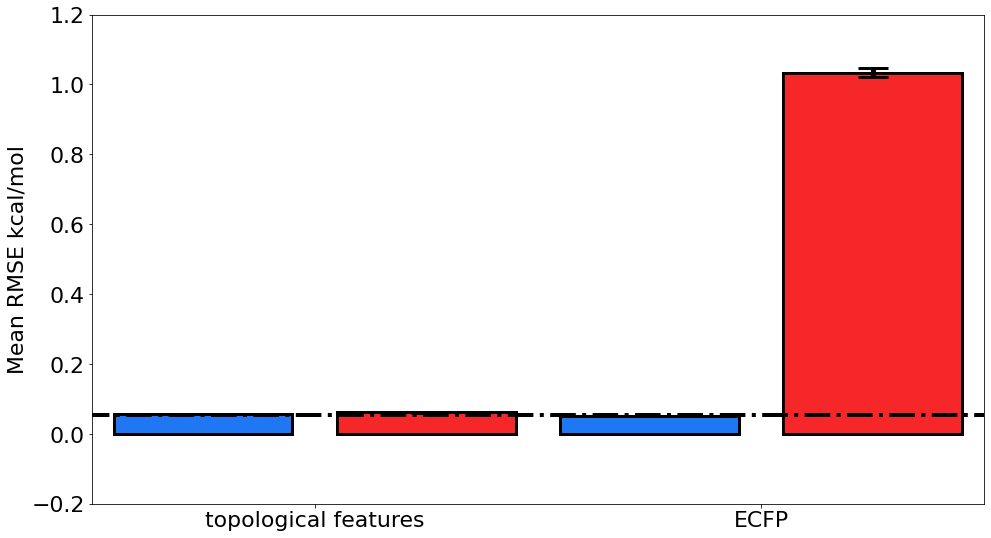

In [256]:
Best=0.053

#data=[dc_NN_MR_small_train_scores_rmse,
#      dc_NN_MR_small_test_scores_rmse,
#      dc_NN_MR_large_train_scores_rmse,
#      dc_NN_MR_large_test_scores_rmse]
      

#x_positions = [1,2,3,4]
# train test
#means=[mean_train_dc_NN_MR_small_rmse, mean_test_dc_NN_MR_small_rmse, mean_train_dc_NN_MR_large_rmse, mean_test_dc_NN_MR_large_rmse]
#stds=[std_error_train_dc_NN_MR_small_rmse, std_error_test_dc_NN_MR_small_rmse, std_error_train_dc_NN_MR_large_rmse, std_error_test_dc_NN_MR_large_rmse]

#means = means[:-4]
#stds = stds[:-4]


x_positions = [x+1 for x in range(len(means))]
plt.figure(figsize=(16, 9))
#plt.fontsize(14)
plt.rcParams.update({'font.size': 22})

plt.bar(x_positions, means, 
        color=["#1f77f4","#f62728","#1f77f4","#f62728"], 
        edgecolor='k',
        linewidth='3',
        yerr=stds, 
        error_kw=dict(lw=5, capsize=15, capthick=3))
#for i in range(4):
#    x=data[i]; plt.plot(np.ones(len(x))*(i+1),x,'o',color="#444444")

plt.plot([0.5,max(x_positions) + 0.5],[Best,Best],'k',linewidth=4,linestyle='-.')
axes=plt.gca()
axes.set_ylim([-0.2,1.2])
plt.xticks([1.5,3.5,5.5,7.5],['','','topological features','ECFP'])
axes.set_xlim([4.5,8.5])
plt.ylabel('Mean RMSE kcal/mol')
plt.savefig(os.path.join(results_dir, "2021_08_06_QM8_rmse_run2.png"))

## Finding 2.

topol and ECFP results above were training on the same type of NN and both sets of hyperparameters were optimised.

The black dot-dashed line is at 0.053 which is the average RMSE error from using the entire dataset (admittedly no optimisation but life is too short) and ECFPs. 

The bars are train and test from hyperparameter optimised runs using topological features (size 18) or ECFP (size 1024).

**Firstly:** topol features beats ECFP on this dataset

**Secondly** topol features is as good (on this test dataset) as a model trained on the larger dataset! N.B. this dataset is 1/10th of the size of the larger dataset. 

## Graph Conv on QM8

broken from here on!

In [147]:
tasks, datasets, transformers = dc.molnet.load_qm8(
   shard_size=2000, featurizer="GraphConv", split="random")
_, _, my_dataset = datasets
## we're jsut going to use the test dataset here to test the code
splitter = dc.splits.RandomSplitter()
train_dataset, valid_dataset, test_dataset = splitter.train_valid_test_split(
  dataset=my_dataset, frac_train=0.8, frac_valid=0.1, frac_test=0.1
)

# RMS, averaged across tasks
avg_rms = dc.metrics.Metric(dc.metrics.rms_score, np.mean)
model = dc.models.GraphConvModel(
   len(tasks), batch_size=128, mode='regression')
# Fit trained model
model.fit(train_dataset, nb_epoch=5)
# We now evaluate our fitted model on our training and validation sets
train_scores = model.evaluate(train_dataset, [avg_rms], transformers)
assert train_scores['mean-rms_score'] < 10.00

valid_scores = model.evaluate(valid_dataset, [avg_rms], transformers)
assert valid_scores['mean-rms_score'] < 10.00

print(f"Train scores average = {train_scores}")
print(f"Validate scores average = {valid_scores}")
print(f"Test scores average = {test_scores}")

'split' is deprecated.  Use 'splitter' instead.


NotImplementedError: in user code:

    C:\Users\ella_\.conda\envs\graphs-and-topology-for-chemists\lib\site-packages\deepchem\models\keras_model.py:474 apply_gradient_for_batch  *
        grads = tape.gradient(batch_loss, vars)
    C:\Users\ella_\.conda\envs\graphs-and-topology-for-chemists\lib\site-packages\tensorflow\python\eager\backprop.py:1073 gradient  **
        unconnected_gradients=unconnected_gradients)
    C:\Users\ella_\.conda\envs\graphs-and-topology-for-chemists\lib\site-packages\tensorflow\python\eager\imperative_grad.py:77 imperative_grad
        compat.as_str(unconnected_gradients.value))
    C:\Users\ella_\.conda\envs\graphs-and-topology-for-chemists\lib\site-packages\tensorflow\python\eager\backprop.py:162 _gradient_function
        return grad_fn(mock_op, *out_grads)
    C:\Users\ella_\.conda\envs\graphs-and-topology-for-chemists\lib\site-packages\tensorflow\python\ops\math_grad.py:470 _UnsortedSegmentSumGrad
        return _GatherDropNegatives(grad, op.inputs[1])[

In [ ]:
splitter = dc.splits.RandomSplitter()
tasks, datasets, transformers = dc.molnet.load_qm8(
   shard_size=2000, featurizer="GraphConv", splitter="random")
train_dataset, valid_dataset, test_dataset = datasets

#train_dataset, valid_dataset, test_dataset = splitter.train_valid_test_split(
#  dataset=my_dataset, frac_train=0.8, frac_valid=0.1, frac_test=0.1
#)
# RMS, averaged across tasks
avg_rms = dc.metrics.Metric(dc.metrics.rms_score, np.mean)
model = dc.models.GraphConvModel(
   len(tasks), batch_size=128, mode='regression')
# Fit trained model
model.fit(train_dataset, nb_epoch=5)
# We now evaluate our fitted model on our training and validation sets
train_scores = model.evaluate(train_dataset, [avg_rms], transformers)
assert train_scores['mean-rms_score'] < 10.00

valid_scores = model.evaluate(valid_dataset, [avg_rms], transformers)
assert valid_scores['mean-rms_score'] < 10.00

print(f"Train scores average = {train_scores}")
print(f"Validate scores average = {valid_scores}")
print(f"Test scores average = {test_scores}")

In [ ]:
splitter = dc.splits.RandomSplitter()
tasks, datasets, transformers = dc.molnet.load_qm8(
   shard_size=2000, featurizer="GraphConv", splitter="random")
_, _, my_dataset = datasets

train_dataset, valid_dataset, test_dataset = splitter.train_valid_test_split(
  dataset=my_dataset, frac_train=0.8, frac_valid=0.1, frac_test=0.1
)
# RMS, averaged across tasks
avg_rms = dc.metrics.Metric(dc.metrics.rms_score, np.mean)
model = dc.models.GraphConvModel(
   len(tasks), batch_size=128, mode='regression')
# Fit trained model
model.fit(train_dataset, nb_epoch=5)
# We now evaluate our fitted model on our training and validation sets
train_scores = model.evaluate(train_dataset, [avg_rms], transformers)
assert train_scores['mean-rms_score'] < 10.00

valid_scores = model.evaluate(valid_dataset, [avg_rms], transformers)
assert valid_scores['mean-rms_score'] < 10.00

print(f"Train scores average = {train_scores}")
print(f"Validate scores average = {valid_scores}")
print(f"Test scores average = {test_scores}")

In [ ]:
train_dataset